In [24]:
import numpy as np
import pandas as pd
import nitools as nit
import nibabel as nib
from nibabel.affines import apply_affine
import matplotlib.pyplot as plt
import seaborn as sns
import cortico_cereb_connectivity.globals as gl
import cortico_cereb_connectivity.evaluation as ev
import Functional_Fusion.dataset as fdata
import Functional_Fusion.atlas_map as am
import cortico_cereb_connectivity.run_model as rm
import cortico_cereb_connectivity.evaluation as ev
import SUITPy as suit

In [2]:
# the atlas
label_img = nib.load(gl.atlas_dir + "/tpl-MNI152NLin6Asym/atl-Platchi5_space-MNI152NLin6Asym_dseg.nii")
label_data = label_img.get_fdata().squeeze()

In [11]:
new_data = np.zeros(label_data.shape, dtype=np.uint8)

for label in range(1, 6):

    vox = np.argwhere(label_data == label)
    xyz = apply_affine(label_img.affine, vox)

    left = xyz[:, 0] < 0
    right = xyz[:, 0] > 0

    # 1L, 1R, 2L, 2R, ...
    left_label = 2 * label - 1
    right_label = 2 * label

    new_data[tuple(vox[left].T)] = left_label
    new_data[tuple(vox[right].T)] = right_label

new_label_img = nib.Nifti1Image(
    new_data,
    label_img.affine,
    label_img.header
)

new_label_data = new_label_img.get_fdata().squeeze()

In [8]:
config = rm.get_train_config(log_alpha=0,
                                 crossed='half',
                                 type='CondHalf',
                                 cond_num='all',
                                 subj_list='all',
                                 cerebellum='MNISymC3',
                                 parcellation='Icosahedron1002',
                                 train_dataset='MDTB',
                                 method='NNLS',
                                 train_ses='all',
                                 add_rest=False,
                                 std_cortex='parcel',
                                 std_cerebellum='global',
                                 cortical_cerebellar_act='ind',
                                 append=False)

In [23]:
subj = rm.get_subj_list('all', 'MDTB')

# Load the data
HH, info, _ = fdata.get_dataset(gl.base_dir,
                                   'MDTB',
                                   sess='all',
                                   subj=subj,
                                   atlas='MNIAsymHippocampus',
                                   type=config["type"])

HH, info_h = rm.prepare_data(HH, info, config)
for i in range(HH.shape[0]):
    if 'std_cortex' in config.keys():
        HH[i,:,:] = rm.std_data(HH[i,:,:], config['std_cortex'])
H = HH.mean(axis=0)

YY, info, _ = fdata.get_dataset(gl.base_dir,
                                   'MDTB',
                                   sess='all',
                                   subj=subj,
                                   atlas=config['cerebellum'],
                                   type=config["type"])

YY, info_y = rm.prepare_data(YY, info, config)
for i in range(YY.shape[0]):
    if 'std_cerebellum' in config.keys():
        YY[i,:,:] = rm.std_data(YY[i,:,:], config['std_cerebellum'])
Y = YY.mean(axis=0)

/home/UWO/ashahb7/Github/cortico_cereb_connectivity/cortico_cereb_connectivity/run_model.py:395: RuntimeWarning: invalid value encountered in divide
  return  np.nan_to_num(Y/sc)


In [27]:
R, _, _, _ = ev.calculate_reliability(H, info_h)
print(f'Hippocamp reliability: {R:.2f}')
R, _, _, _ = ev.calculate_reliability(Y, info_y)
print(f'Cerebellum reliability: {R:.2f}')

Hippocamp reliability: 0.76
Cerebellum reliability: 0.86


In [13]:
print(new_label_data.shape)
print(H.shape)
print(f"Number of labeled Hippocampal voxels: {np.sum(new_label_data > 0)}")
print(Y.shape)

(91, 109, 91)
(122, 1559)
Number of labeled Hippocampal voxels: 1559
(122, 5446)


In [14]:
def calc_corr(H, Y):
    # should already be zero mean
    A = H - H.mean(axis=0, keepdims=True)
    B = Y - Y.mean(axis=0, keepdims=True)

    A /= np.linalg.norm(A, axis=0, keepdims=True) # should already be norm 1
    B /= np.linalg.norm(B, axis=0, keepdims=True)

    return A.T @ B

In [17]:
cereb_atlas, cereb_ainf = am.get_atlas('MNISymC3')
hipp_atlas, hipp_ainf = am.get_atlas('Platchi5')
label_vec, labels = hipp_atlas.get_parcel(new_label_img)
names = ['1L', '1R', '2L', '2R', '3L', '3R', '4L', '4R', '5L', '5R']
print(labels)

[ 1  2  3  4  5  6  7  8  9 10]


In [18]:
# aggregate data within each label
Hl = np.zeros((H.shape[0], len(labels)))
for i, label in enumerate(labels):
    Hl[:, i] = H[:, label_vec == label].mean(axis=1)

In [19]:
corr = calc_corr(Hl, Y)

/localscratch/tmp/ipykernel_1617903/2844972330.py:7: RuntimeWarning: invalid value encountered in divide
  B /= np.linalg.norm(B, axis=0, keepdims=True)


<Axes: >

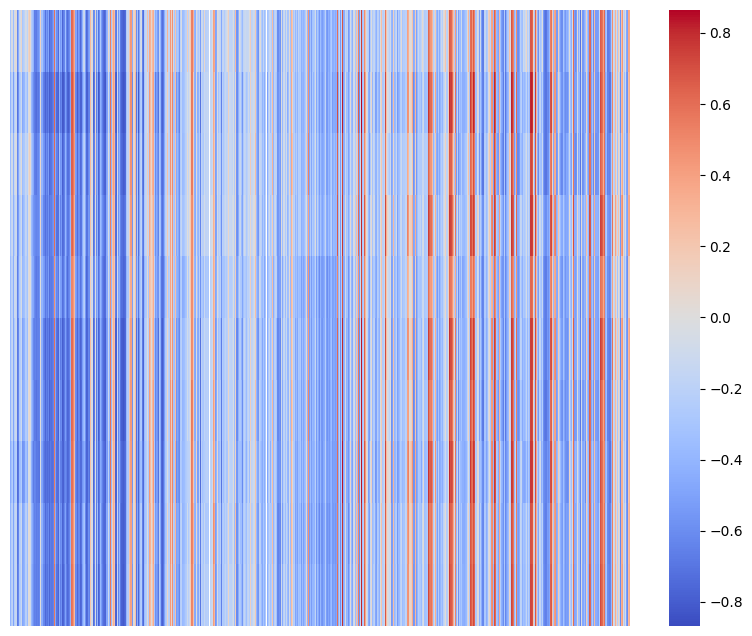

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, xticklabels=False, yticklabels=False)

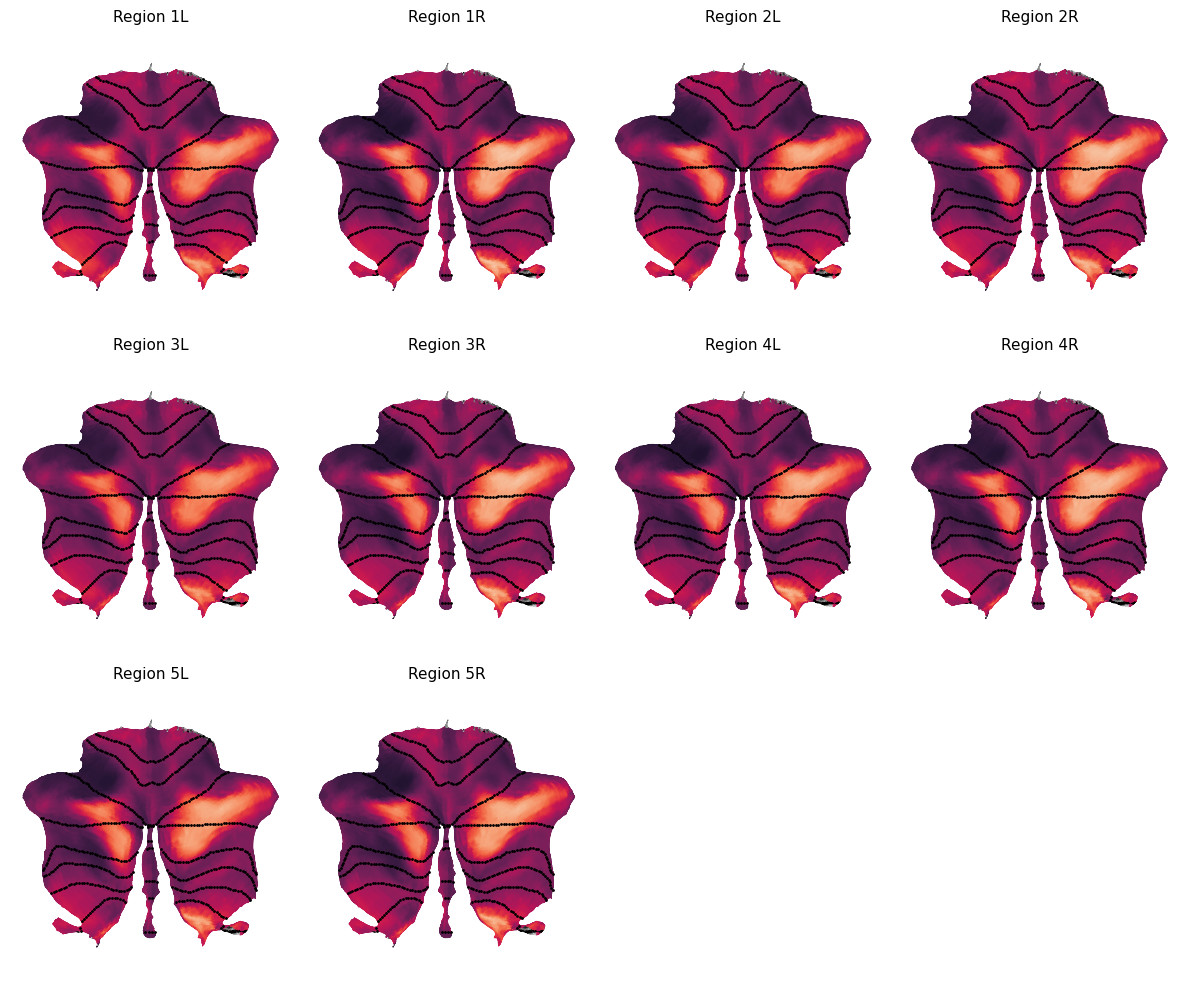

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(12, 10))
for i, (label, name) in enumerate(zip(labels, names)):
    corr_vec = corr[i, :]
    nifti_image = cereb_atlas.data_to_nifti(corr_vec)
    data = suit.vol_to_surf(nifti_image, space='MNISymC')

    plt.subplot(3, 4, i+1)
    suit.flatmap.plot(data, cmap='rocket', new_figure=False, cscale=[-1, 1])
    plt.title(f'Region {name}', fontsize=11)

plt.subplot(3, 4, 11).axis('off')
plt.subplot(3, 4, 12).axis('off')
plt.tight_layout();